# Q3 — Career Switching vs. Salary and Satisfaction

**Question:** Do people who switched careers into data differ in salary or satisfaction from those who didn't?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


In [2]:
career_switch = df.groupby("switched_careers").agg(
    median_salary=("salary_midpoint", "median"),
    mean_salary=("salary_midpoint", "mean"),
    mean_composite_satisfaction=("satisfaction_composite", "mean"),
    n=("respondent_id", "count"),
)
career_switch

,median_salary,mean_salary,mean_composite_satisfaction,n
switched_careers,,,,
No,"53,000.00","52,577.52",5.01,258
Yes,"53,000.00","54,956.99",5.41,372


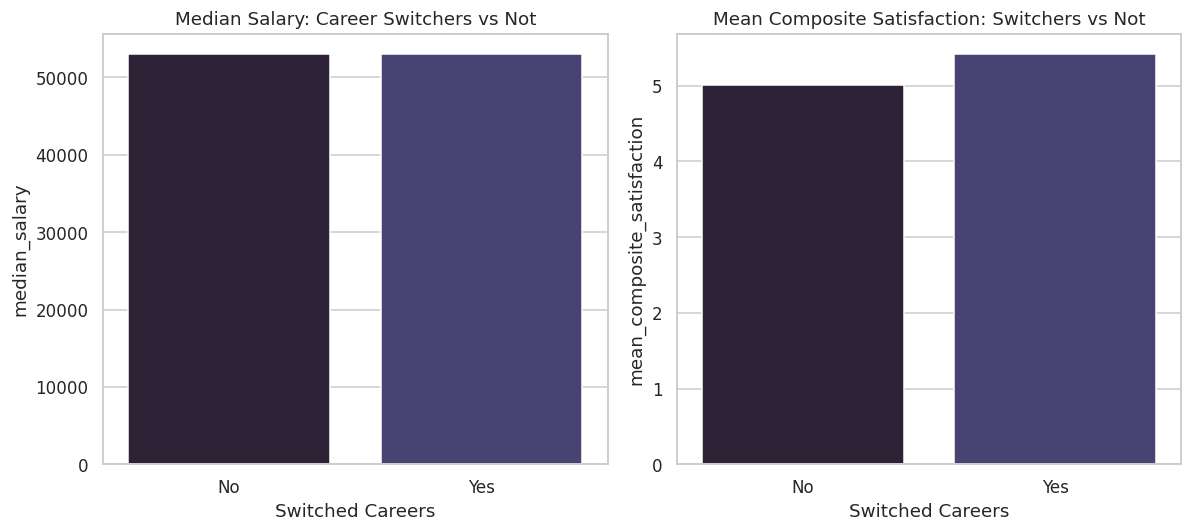

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
data = career_switch.reset_index()

sns.barplot(data=data, x="switched_careers", y="median_salary", ax=axes[0],
            hue="switched_careers", legend=False)
axes[0].set_title("Median Salary: Career Switchers vs Not")
axes[0].set_xlabel("Switched Careers")

sns.barplot(data=data, x="switched_careers", y="mean_composite_satisfaction", ax=axes[1],
            hue="switched_careers", legend=False)
axes[1].set_title("Mean Composite Satisfaction: Switchers vs Not")
axes[1].set_xlabel("Switched Careers")

fig.tight_layout()
fig.savefig(OUT / "q3_career_switch_impact.png", bbox_inches="tight")
plt.show()

**Takeaway:** Career switchers report slightly *higher* median satisfaction (5.41 vs 5.01) and comparable salary to non-switchers — switching doesn't appear to be a costly move in this sample.

# Q3b — Career Switching Deep Dive: Role Profiles, Full Satisfaction Breakdown, Education & Gender

**Question:** Beyond salary alone: how does switching careers relate to every satisfaction dimension, and who is switching (by education, by gender)?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

DIMS = ["satisfaction_salary", "satisfaction_worklife", "satisfaction_coworkers",
        "satisfaction_management", "satisfaction_mobility", "satisfaction_learning"]

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


In [2]:
role_profile = df.groupby("role_name").agg(
    respondents=("respondent_id", "count"),
    avg_salary=("salary_midpoint", "mean"),
    avg_sat_salary=("satisfaction_salary", "mean"),
    avg_sat_worklife=("satisfaction_worklife", "mean"),
    avg_sat_coworkers=("satisfaction_coworkers", "mean"),
    avg_sat_management=("satisfaction_management", "mean"),
    avg_sat_mobility=("satisfaction_mobility", "mean"),
    avg_sat_learning=("satisfaction_learning", "mean"),
    avg_composite=("satisfaction_composite", "mean"),
).sort_values("avg_composite", ascending=False)
role_profile

,respondents,avg_salary,avg_sat_salary,avg_sat_worklife,avg_sat_coworkers,avg_sat_management,avg_sat_mobility,avg_sat_learning,avg_composite
role_name,,,,,,,,,
Data Scientist,25,"94,780.00",5.68,6.12,6.76,6.12,5.56,6.84,6.18
Database Developer,5,"33,200.00",4.40,6.40,6.60,6.80,5.20,6.80,6.03
Data Engineer,38,"65,750.00",4.34,5.92,5.92,5.24,5.16,6.45,5.51
Data Analyst,381,"55,297.90",4.49,6.00,6.09,5.59,5.02,5.90,5.50
Other,88,"60,494.32",4.53,6.01,6.12,5.53,4.70,5.07,5.33
Data Architect,3,"63,666.67",5.67,4.67,4.33,4.33,5.67,6.67,5.22


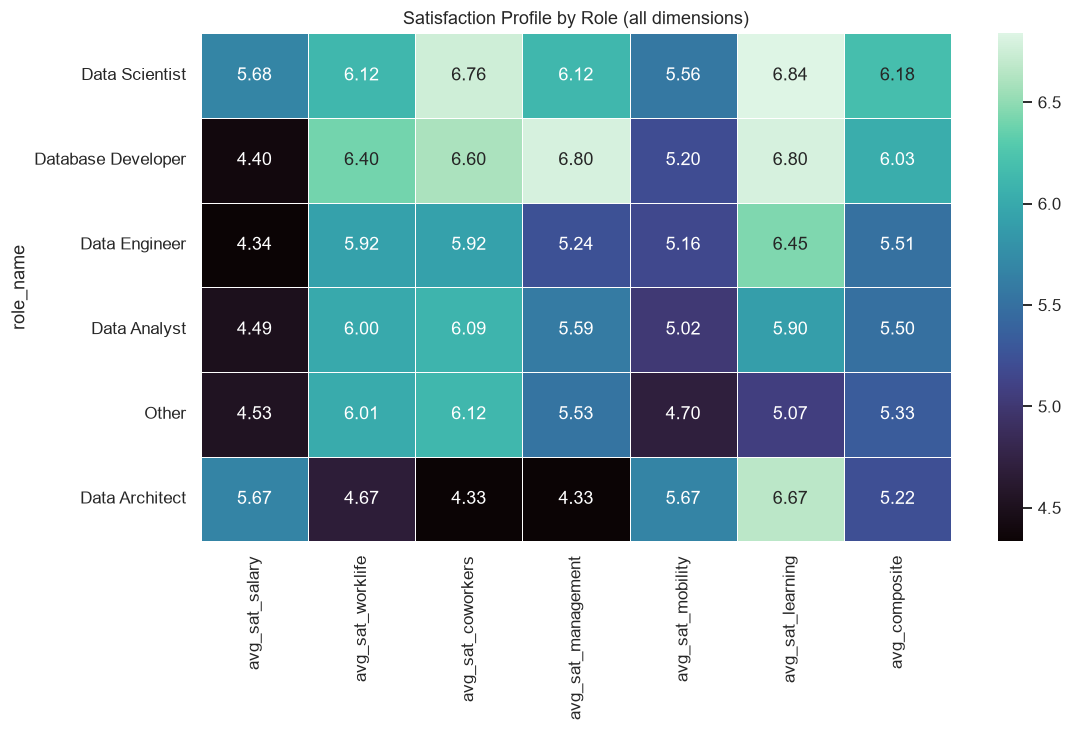

In [3]:
fig, ax = plt.subplots(figsize=(11, 6))
heat_cols = ["avg_sat_salary", "avg_sat_worklife", "avg_sat_coworkers",
             "avg_sat_management", "avg_sat_mobility", "avg_sat_learning", "avg_composite"]
sns.heatmap(role_profile[heat_cols], annot=True, fmt=".2f", cmap="mako", linewidths=0.5, ax=ax)
ax.set_title("Satisfaction Profile by Role (all dimensions)")
fig.savefig(OUT / "q3b_role_satisfaction_profile_heatmap.png", bbox_inches="tight")
plt.show()

In [4]:
switch_rows = []
for dim in DIMS + ["satisfaction_composite"]:
    switch_rows.append({
        "dimension": dim.replace("satisfaction_", ""),
        "switchers": df.loc[df["switched_careers"] == "Yes", dim].mean(),
        "non_switchers": df.loc[df["switched_careers"] == "No", dim].mean(),
    })
switch_satisfaction = pd.DataFrame(switch_rows).set_index("dimension")
switch_satisfaction["gap"] = switch_satisfaction["switchers"] - switch_satisfaction["non_switchers"]
switch_satisfaction

,switchers,non_switchers,gap
dimension,,,
salary,4.36,4.14,0.22
worklife,5.77,5.71,0.06
coworkers,5.96,5.72,0.24
management,5.44,5.17,0.27
mobility,5.08,4.30,0.78
learning,5.95,5.11,0.84
composite,5.41,5.01,0.40


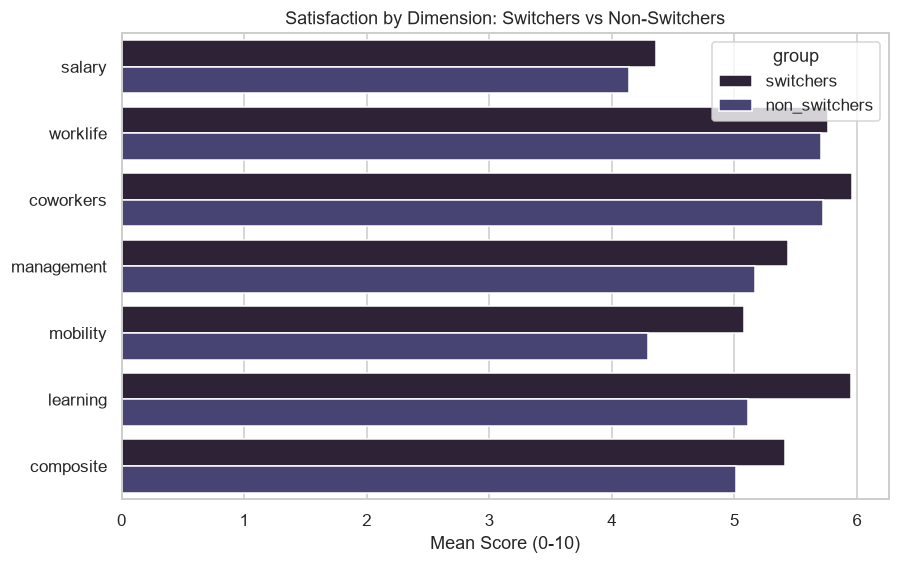

In [5]:
fig, ax = plt.subplots(figsize=(9, 5.5))
data = switch_satisfaction[["switchers", "non_switchers"]].reset_index().melt(
    id_vars="dimension", var_name="group", value_name="score")
sns.barplot(data=data, y="dimension", x="score", hue="group", ax=ax)
ax.set_title("Satisfaction by Dimension: Switchers vs Non-Switchers")
ax.set_xlabel("Mean Score (0-10)")
ax.set_ylabel("")
fig.savefig(OUT / "q3b_switchers_vs_nonswitchers_all_dims.png", bbox_inches="tight")
plt.show()

### Who's switching: by education level

In [6]:
switch_by_education = df.groupby("education").agg(
    total=("respondent_id", "count"),
    switchers=("switched_careers", lambda s: (s == "Yes").sum()),
    non_switchers=("switched_careers", lambda s: (s == "No").sum()),
)
switch_by_education["pct_switched"] = (
    100 * switch_by_education["switchers"] / switch_by_education["total"]
).round(1)
switch_by_education = switch_by_education.sort_values("pct_switched", ascending=False)
switch_by_education

,total,switchers,non_switchers,pct_switched
education,,,,
PhD,5,4,1,80.00
None,52,34,18,65.40
Bachelors,329,196,133,59.60
Masters,192,110,82,57.30
Associates,16,9,7,56.20
High School,36,19,17,52.80


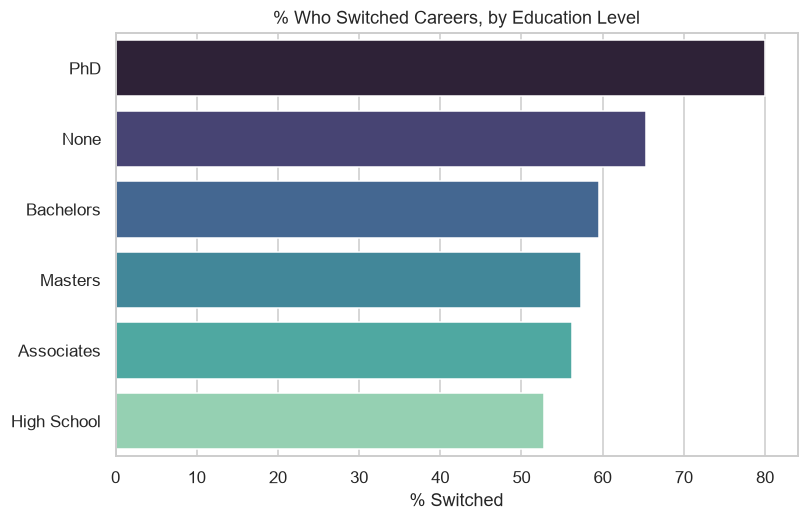

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
data = switch_by_education.reset_index()
sns.barplot(data=data, y="education", x="pct_switched", ax=ax, hue="education", legend=False)
ax.set_title("% Who Switched Careers, by Education Level")
ax.set_xlabel("% Switched")
ax.set_ylabel("")
fig.savefig(OUT / "q3b_pct_switched_by_education.png", bbox_inches="tight")
plt.show()

### Who's switching: by gender

In [10]:
switch_by_gender = df.groupby("gender").agg(
    total=("respondent_id", "count"),
    switchers=("switched_careers", lambda s: (s == "Yes").sum()),
    non_switchers=("switched_careers", lambda s: (s == "No").sum()),
)
switch_by_gender["pct_switched"] = (
    100 * switch_by_gender["switchers"] / switch_by_gender["total"]
).round(1)
switch_by_gender = switch_by_gender.sort_values("pct_switched")
switch_by_gender

,total,switchers,non_switchers,pct_switched
gender,,,,
Male,468,275,193,58.80
Female,162,97,65,59.90


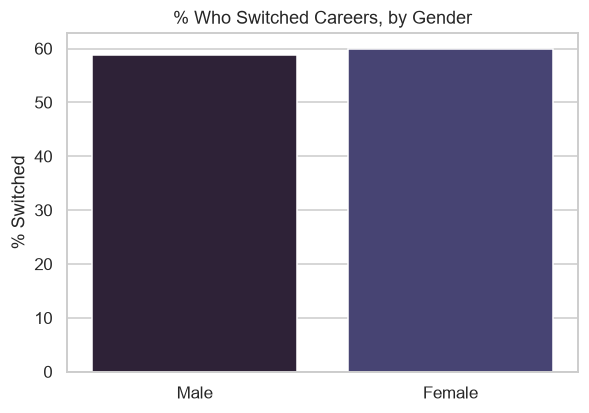

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
data = switch_by_gender.reset_index()
sns.barplot(data=data, x="gender", y="pct_switched", ax=ax, hue="gender", legend=False)
ax.set_title("% Who Switched Careers, by Gender")
ax.set_ylabel("% Switched")
ax.set_xlabel("")
fig.savefig(OUT / "q3b_pct_switched_by_gender.png", bbox_inches="tight")
plt.show()

**Takeaway:** Switchers report higher satisfaction across nearly every dimension, not just the composite — worklife and learning show the widest gaps. Switching rates vary meaningfully by education level, with some groups switching in at notably higher rates than others.